# Clasificación de COVID-19 a partir del sonido de la tos

**Curso:** Machine Learning — Maestría en AI/DS, UTEC
**Profesor:** Cristian López Del Alamo
**Integrantes:** Roger Reátegui Soto, Erick Rosas Pisfil, Yemar Puma Huamán
**Repositorio:** https://github.com/erosas-utec/ml-project-classification

## 1. Introducción

El objetivo de este proyecto es clasificar pacientes como COVID positivo o negativo usando **únicamente el sonido de su tos**. El dataset viene de las colecciones COSWARA y Virufy e incluye 1207 toses de personas con prueba negativa y 150 de personas positivas.

El plan de trabajo es el siguiente:

1. Cargar y limpiar el dataset de audios.
2. Convertir cada audio en un vector de características usando **MFCC** (la misma técnica que usamos en la hackathon de clasificación gato/perro).
3. Entrenar y comparar **Regresión Logística, SVM, Árbol de Decisión y KNN** (los 4 modelos que pide el proyecto), más **Random Forest** como método más avanzado (visto en el capítulo de árboles del curso).
4. Hacer todo el proceso de entrenamiento con **validación cruzada K-fold (K=5)**, probando varios hiperparámetros por modelo y reportando Accuracy, Precision, Recall y F1 en cada prueba.
5. Evaluar el mejor modelo con un conjunto de **test (20%)** que se separa al inicio y no se toca hasta el final, generando la matriz de confusión con los porcentajes por clase.

Fijo una **semilla** en todo el proyecto para que los resultados sean 100% replicables.

In [1]:
# Librerías que voy a usar en todo el proyecto
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report, make_scorer)

warnings.filterwarnings('ignore')  # librosa avisa cosas de los mp3 que no afectan el resultado

# Fijo la semilla para que todo el proyecto sea replicable (requisito del curso)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Constantes del proyecto
SR = 22050        # frecuencia de muestreo única: los audios vienen mezclados en 44.1 kHz y 48 kHz
N_MFCC = 20       # número de coeficientes MFCC (igual que en la hackathon gato/perro)
DATA_DIR = Path('../Proyecto_clasificacion/cough_sounds/cleaned_data')  # ajustar si el dataset está en otra ruta
FEATURES_CSV = Path('data/features.csv')

# Estilo de las gráficas: paleta apta para daltonismo y en orden fijo
sns.set_theme(style='whitegrid')
PALETA = sns.color_palette('colorblind')

## 2. Carga y exploración de los datos

Los audios están en tres carpetas: `Negative`, `Positive` y `Unknown`. El nombre de cada archivo sigue el patrón `id_Etiqueta_genero_edad`, por ejemplo `0_Negative_male_26.wav`.

Al revisar el dataset encontré varios detalles que hay que manejar antes de entrenar:

- **Uso la carpeta como etiqueta**, no el nombre del archivo: 9 archivos tienen el typo `Postive` en el nombre.
- La carpeta `Positive` mezcla formatos: 102 `.wav` y 48 `.mp3`. **Conservo los mp3** porque librosa los lee sin problema y los positivos son justo la clase escasa.
- La carpeta `Unknown` (73 audios) **no tiene etiqueta**, así que no sirve ni para entrenar ni para medir métricas: la descarto.
- Hay **5 pacientes positivos con varias grabaciones** (por ejemplo el paciente 1521 tiene 22 audios). Verifiqué con hashes que son grabaciones distintas, no copias, así que las conservo — pero más adelante me aseguro de que todas las grabaciones de un mismo paciente caigan en el mismo conjunto (train o test).
- La edad y el género quedan solo como datos descriptivos (además hay edades mal registradas, como 356): el proyecto pide clasificar **solo con el sonido**.

In [2]:
# Recorro las carpetas Negative y Positive y armo una tabla con la información de cada audio
registros = []
for clase in ['Negative', 'Positive']:
    for archivo in sorted((DATA_DIR / clase).glob('*')):
        if archivo.suffix.lower() not in ['.wav', '.mp3']:
            continue
        nombre = archivo.stem                 # ej: '0_Negative_male_26' o '1524_Postive_male_356 (1)'
        partes = nombre.split('_')
        registros.append({
            'archivo': archivo.name,
            'ruta': str(archivo),
            'clase': clase,                   # la CARPETA es la etiqueta confiable
            'id_paciente': partes[0],
            'genero': partes[2],
            'edad': partes[3].split(' ')[0],  # le quito el sufijo ' (n)' de las grabaciones repetidas
            'formato': archivo.suffix.lower(),
        })

df = pd.DataFrame(registros)
df['y'] = (df['clase'] == 'Positive').astype(int)   # 1 = COVID positivo, 0 = negativo

print('Total de audios:', len(df))
print()
print(df['clase'].value_counts())
print()
print(df.groupby('clase')['formato'].value_counts())
df.head()

Total de audios: 1357

clase
Negative    1207
Positive     150
Name: count, dtype: int64

clase     formato
Negative  .wav       1207
Positive  .wav        102
          .mp3         48
Name: count, dtype: int64


,archivo,ruta,clase,id_paciente,genero,edad,formato,y
0,0_Negative_male_26.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,0,male,26,.wav,0
1,1001_Negative_male_30.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1001,male,30,.wav,0
2,1002_Negative_male_27.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1002,male,27,.wav,0
3,1003_Negative_male_30.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1003,male,30,.wav,0
4,1004_Negative_male_29.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1004,male,29,.wav,0


Pacientes únicos por clase:
clase
Negative    1207
Positive     117
Name: id_paciente, dtype: int64

Pacientes con más de una grabación:
id_paciente
1521    22
1524     7
1523     5
1503     2
1522     2
Name: count, dtype: int64


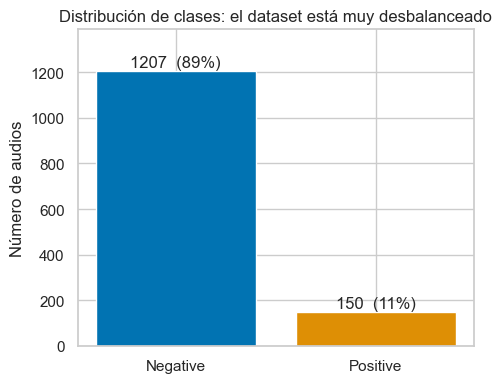

In [3]:
# Reviso el desbalance de clases y los pacientes con más de una grabación
print('Pacientes únicos por clase:')
print(df.groupby('clase')['id_paciente'].nunique())

repetidos = df['id_paciente'].value_counts()
print()
print('Pacientes con más de una grabación:')
print(repetidos[repetidos > 1])

fig, ax = plt.subplots(figsize=(5, 4))
conteo = df['clase'].value_counts()
ax.bar(conteo.index, conteo.values, color=[PALETA[0], PALETA[1]])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 15, f'{v}  ({v / len(df):.0%})', ha='center')
ax.set_ylim(0, conteo.max() * 1.15)
ax.set_ylabel('Número de audios')
ax.set_title('Distribución de clases: el dataset está muy desbalanceado')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Extracción de características con MFCC

Un audio crudo es una señal muy larga y de duración variable (aquí van de 2.5 s a 26 s), así que no se puede usar directo como entrada de los modelos. El proyecto permite usar librerías para obtener el mejor vector de características, y yo uso los **MFCC (Mel-Frequency Cepstral Coefficients)** de `librosa`, que resumen el timbre del sonido en pocas dimensiones y nos funcionaron bien en la hackathon de gato/perro.

Para cada audio calculo la matriz de 20 MFCC por ventana de tiempo y la resumo con la **media y la desviación estándar** de cada coeficiente → un vector fijo de **40 features** por audio, sin importar cuánto dure. Además, `librosa.load` resamplea todo a 22050 Hz, con lo que se soluciona que los audios vengan en 44.1 y 48 kHz mezclados.

Como extraer los MFCC de ~1350 audios toma unos minutos, guardo el resultado en `data/features.csv`: si el archivo ya existe, lo cargo directo (el cálculo es determinista, da lo mismo).

In [4]:
def extraer_features(ruta):
    """Carga un audio y devuelve su vector de 40 features (media y std de 20 MFCC) y su duración."""
    senal, sr = librosa.load(ruta, sr=SR)
    mfcc = librosa.feature.mfcc(y=senal, sr=sr, n_mfcc=N_MFCC)   # matriz (20, n_ventanas)
    vector = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])
    return vector, len(senal) / sr


columnas_feat = [f'mfcc_mean_{i}' for i in range(N_MFCC)] + [f'mfcc_std_{i}' for i in range(N_MFCC)]

if FEATURES_CSV.exists():
    df_feat = pd.read_csv(FEATURES_CSV, dtype={'id_paciente': str})
    print('Features cargadas desde', FEATURES_CSV)
else:
    filas, fallidos = [], []
    for i, audio in df.iterrows():
        try:
            vector, duracion = extraer_features(audio['ruta'])
            filas.append(list(vector) + [duracion])
        except Exception as error:
            fallidos.append((audio['archivo'], str(error)))
            filas.append([np.nan] * N_MFCC * 2 + [np.nan])
        if (i + 1) % 200 == 0:
            print(f'  procesados {i + 1} de {len(df)} audios...')

    df_feat = pd.concat([df.reset_index(drop=True),
                         pd.DataFrame(filas, columns=columnas_feat + ['duracion_s'])], axis=1)
    df_feat = df_feat.dropna(subset=columnas_feat).reset_index(drop=True)
    print('Audios que no se pudieron leer:', len(fallidos), fallidos[:5])
    FEATURES_CSV.parent.mkdir(exist_ok=True)
    df_feat.to_csv(FEATURES_CSV, index=False)
    print('Features guardadas en', FEATURES_CSV)

print('Tabla final de features:', df_feat.shape)
df_feat.head()

Features cargadas desde data\features.csv
Tabla final de features: (1357, 49)


,archivo,ruta,clase,id_paciente,genero,edad,formato,y,mfcc_mean_0,mfcc_mean_1,...,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_std_14,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,duracion_s
0,0_Negative_male_26.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,0,male,26,.wav,0,-340.55215,66.880646,...,12.314476,9.836579,8.982395,10.383850,10.142530,7.343030,8.333507,10.032979,7.666974,5.973333
1,1001_Negative_male_30.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1001,male,30,.wav,0,-283.26370,85.185930,...,16.415142,13.796118,14.757615,9.710491,8.326899,11.713878,10.451915,8.480636,9.081613,6.058685
2,1002_Negative_male_27.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1002,male,27,.wav,0,-475.69830,57.115220,...,8.263861,8.920180,11.147167,9.908153,4.594748,6.948964,7.243165,6.947069,5.681151,4.608027
3,1003_Negative_male_30.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1003,male,30,.wav,0,-347.25577,27.227205,...,8.474210,11.683063,11.065142,10.090658,11.602316,7.598847,9.883102,7.461547,7.870695,10.154694
4,1004_Negative_male_29.wav,..\Proyecto_clasificacion\cough_sounds\cleaned...,Negative,1004,male,29,.wav,0,-398.64404,58.635323,...,7.992653,8.589902,9.154720,8.590487,7.404130,10.150194,9.226245,8.549302,6.414618,3.242676


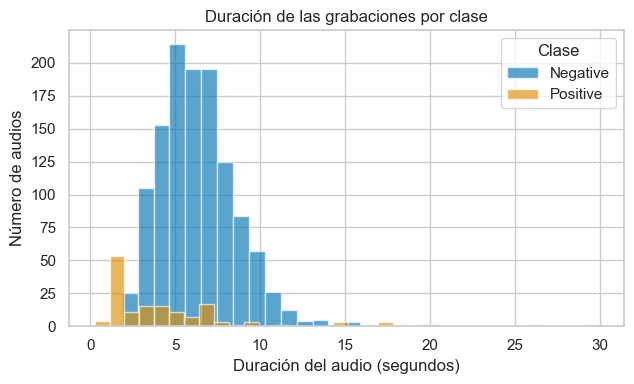

,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
Negative,1207.0,6.34,2.30,1.86,4.78,6.14,7.59,29.95
Positive,150.0,4.49,4.22,0.26,1.60,3.29,6.06,26.62


In [5]:
# Exploro las duraciones por clase (solo descriptivo, los MFCC ya normalizan la duración)
fig, ax = plt.subplots(figsize=(6.5, 4))
for clase, color in [('Negative', PALETA[0]), ('Positive', PALETA[1])]:
    ax.hist(df_feat.loc[df_feat['clase'] == clase, 'duracion_s'],
            bins=30, alpha=0.65, label=clase, color=color)
ax.set_xlabel('Duración del audio (segundos)')
ax.set_ylabel('Número de audios')
ax.set_title('Duración de las grabaciones por clase')
ax.legend(title='Clase')
plt.tight_layout()
plt.savefig('figures/duraciones.png', dpi=150, bbox_inches='tight')
plt.show()

df_feat.groupby('clase')['duracion_s'].describe().round(2)

## 4. Los modelos que voy a comparar

Una explicación corta de cada modelo, según lo que vimos en el curso:

- **Regresión Logística** (Cap. 2.1): aplica la función sigmoide sobre una combinación lineal de las features y devuelve la probabilidad de ser positivo. Se entrena minimizando la log-loss con descenso de gradiente. Su hiperparámetro principal es `C`, el inverso de la regularización L2 (C pequeño = más regularización).
- **SVM** (Cap. 2.2): busca el hiperplano que separa las clases **maximizando el margen**. Con el *soft margin* (`C`) tolera algunos errores, y con los **kernels** (lineal, RBF) puede separar datos que no son linealmente separables llevándolos a una dimensión mayor.
- **Árbol de Decisión** (Cap. 2.3): divide los datos con preguntas sobre las features, eligiendo en cada nodo la división que más reduce el desorden, medido con **entropía (ganancia de información)** o con **impureza de Gini**. Su principal riesgo es el **overfitting**, que se controla limitando la profundidad (`max_depth`).
- **KNN** (Cap. 2.4): clasifica cada audio por **votación de sus K vecinos más cercanos**. No tiene fase de entrenamiento (*lazy learning*). Hay que tener cuidado con la *curse of dimensionality*; con 40 features todavía trabaja bien.
- **Random Forest** (Cap. 2.3, lo incluyo como el "método más avanzado" que permite el enunciado): es **bagging de árboles de decisión** con aleatoriedad extra en las features, lo que reduce el overfitting del árbol individual.

**Sobre las métricas** (Cap. 2.5): con un dataset 89/11, el accuracy solo engaña — un modelo que diga "todos negativos" ya tendría ~89% de accuracy sin detectar ni un caso de COVID. Por eso reporto también **balanced accuracy** y mido **precision, recall y F1 sobre la clase positiva**, que es la que interesa detectar. El F1 de la clase positiva es la métrica con la que elijo la mejor configuración.

## 5. Separación train/test y escalado

Separo el **20% para test** de forma **estratificada** (mantiene la proporción 89/11) y **a nivel de paciente**: primero reparto los pacientes y después asigno sus grabaciones. Así, si un paciente tiene varias grabaciones, todas quedan en el mismo conjunto — si no, el modelo podría "reconocer" al paciente en el test y las métricas saldrían infladas (fuga de datos).

Este test de 20% es el que uso al final como el "test data" que pide el proyecto para la matriz de confusión.

Después **estandarizo** las features (Cap. 2.1 recomienda normalizar): ajusto el `StandardScaler` **solo con train** y aplico esa misma transformación al test, para no filtrar información del test hacia el entrenamiento.

In [6]:
# Reparto los PACIENTES (no los audios) entre train y test, estratificando por clase
pacientes = df_feat[['id_paciente', 'y']].drop_duplicates('id_paciente')
pac_train, pac_test = train_test_split(pacientes['id_paciente'], test_size=0.20,
                                       stratify=pacientes['y'], random_state=SEED)

train = df_feat[df_feat['id_paciente'].isin(pac_train)]
test = df_feat[df_feat['id_paciente'].isin(pac_test)]

X_train = train[columnas_feat].values
y_train = train['y'].values
grupos_train = train['id_paciente'].values   # para que el K-fold también respete a los pacientes
X_test = test[columnas_feat].values
y_test = test['y'].values

# Estandarizo: el scaler se ajusta SOLO con train
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {len(train)} audios de {len(pac_train)} pacientes '
      f'({train["y"].mean():.1%} positivos)')
print(f'Test:  {len(test)} audios de {len(pac_test)} pacientes '
      f'({test["y"].mean():.1%} positivos)')

Train: 1067 audios de 1059 pacientes (9.6% positivos)
Test:  290 audios de 265 pacientes (16.6% positivos)


## 6. Experimentos con validación cruzada K-fold

Todo el proceso de selección de hiperparámetros se hace **solo con el train (80%)** usando **validación cruzada de 5 folds**. Uso `StratifiedGroupKFold`: *estratificado* para que cada fold mantenga la proporción 89/11 y *agrupado* para que las grabaciones de un mismo paciente no queden repartidas entre folds (la misma razón del split de test).

Para cada combinación de hiperparámetros entreno 5 veces y reporto el **promedio** de: Accuracy, Balanced Accuracy, Precision, Recall y F1 (las últimas tres sobre la clase positiva = detectar COVID), que es la tabla que pide el proyecto.

In [7]:
kfold = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

# precision/recall/f1 con zero_division=0: si un modelo no predice ningún positivo,
# la métrica vale 0 en vez de dar error
metricas = {
    'accuracy': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
}


def evaluar(modelo, X):
    """Corre la validación cruzada de 5 folds sobre el train y devuelve el promedio de cada métrica."""
    cv = cross_validate(modelo, X, y_train, groups=grupos_train, cv=kfold, scoring=metricas)
    return {m: round(cv['test_' + m].mean(), 3) for m in metricas}

### 6.1 Regresión Logística

Pruebo tres niveles de regularización con `C` (inverso de la fuerza de la regularización L2).

In [8]:
resultados = []
for C in [0.1, 1, 10]:
    modelo = LogisticRegression(C=C, max_iter=5000, random_state=SEED)
    resultados.append({'C': C, **evaluar(modelo, X_train)})

tabla_lr = pd.DataFrame(resultados)
tabla_lr

,C,accuracy,balanced_acc,precision,recall,f1
0,0.1,0.903,0.521,0.433,0.049,0.087
1,1.0,0.900,0.537,0.399,0.089,0.142
2,10.0,0.897,0.535,0.366,0.089,0.139


### 6.2 SVM

Pruebo el kernel lineal y el RBF, cada uno con tres valores de `C` (margen suave). `gamma` queda en `'scale'`, el valor automático de sklearn.

In [9]:
resultados = []
for kernel in ['linear', 'rbf']:
    for C in [0.1, 1, 10]:
        modelo = SVC(kernel=kernel, C=C, gamma='scale', random_state=SEED)
        resultados.append({'kernel': kernel, 'C': C, **evaluar(modelo, X_train)})

tabla_svm = pd.DataFrame(resultados)
tabla_svm

,kernel,C,accuracy,balanced_acc,precision,recall,f1
0,linear,0.1,0.904,0.500,0.000,0.000,0.000
1,linear,1.0,0.904,0.500,0.000,0.000,0.000
2,linear,10.0,0.904,0.500,0.000,0.000,0.000
3,rbf,0.1,0.904,0.500,0.000,0.000,0.000
4,rbf,1.0,0.910,0.530,0.800,0.060,0.110
5,rbf,10.0,0.905,0.615,0.522,0.255,0.339


### 6.3 Árbol de Decisión

Comparo los dos criterios de división que vimos en el curso (Gini y entropía) y varias profundidades máximas para controlar el overfitting (`None` = sin límite).

In [10]:
resultados = []
for criterio in ['gini', 'entropy']:
    for profundidad in [3, 5, 10, None]:
        modelo = DecisionTreeClassifier(criterion=criterio, max_depth=profundidad, random_state=SEED)
        resultados.append({'criterion': criterio, 'max_depth': str(profundidad),
                           **evaluar(modelo, X_train)})

tabla_dt = pd.DataFrame(resultados)
tabla_dt

,criterion,max_depth,accuracy,balanced_acc,precision,recall,f1
0,gini,3,0.900,0.511,0.167,0.030,0.051
1,gini,5,0.895,0.548,0.344,0.118,0.172
2,gini,10,0.868,0.555,0.218,0.169,0.190
3,gini,None,0.858,0.581,0.229,0.238,0.233
4,entropy,3,0.899,0.527,0.333,0.068,0.100
5,entropy,5,0.879,0.552,0.283,0.147,0.192
6,entropy,10,0.850,0.567,0.216,0.216,0.214
7,entropy,None,0.839,0.569,0.203,0.236,0.218


### 6.4 KNN

Pruebo varios valores de K y las dos formas de votar: `uniform` (todos los vecinos pesan igual) y `distance` (los vecinos más cercanos pesan más).

In [11]:
resultados = []
for k in [3, 5, 7, 11]:
    for pesos in ['uniform', 'distance']:
        modelo = KNeighborsClassifier(n_neighbors=k, weights=pesos)
        resultados.append({'n_neighbors': k, 'weights': pesos, **evaluar(modelo, X_train)})

tabla_knn = pd.DataFrame(resultados)
tabla_knn

,n_neighbors,weights,accuracy,balanced_acc,precision,recall,f1
0,3,uniform,0.906,0.588,0.531,0.195,0.283
1,3,distance,0.906,0.588,0.531,0.195,0.283
2,5,uniform,0.913,0.570,0.730,0.147,0.242
3,5,distance,0.914,0.575,0.750,0.157,0.256
4,7,uniform,0.912,0.548,0.833,0.098,0.174
5,7,distance,0.915,0.558,0.933,0.117,0.206
6,11,uniform,0.907,0.515,0.600,0.029,0.055
7,11,distance,0.908,0.520,0.800,0.039,0.074


### 6.5 Random Forest (método más avanzado)

Bagging de árboles (Cap. 2.3). Pruebo el número de árboles y la profundidad máxima.

In [12]:
resultados = []
for n_arboles in [100, 200]:
    for profundidad in [5, 10, None]:
        modelo = RandomForestClassifier(n_estimators=n_arboles, max_depth=profundidad,
                                        random_state=SEED)
        resultados.append({'n_estimators': n_arboles, 'max_depth': str(profundidad),
                           **evaluar(modelo, X_train)})

tabla_rf = pd.DataFrame(resultados)
tabla_rf

,n_estimators,max_depth,accuracy,balanced_acc,precision,recall,f1
0,100,5,0.906,0.510,0.4,0.02,0.038
1,100,10,0.906,0.514,0.4,0.03,0.055
2,100,None,0.907,0.519,0.6,0.04,0.074
3,200,5,0.906,0.510,0.4,0.02,0.038
4,200,10,0.907,0.515,0.4,0.03,0.055
5,200,None,0.908,0.520,0.6,0.04,0.074


## 7. Comparación entre modelos

Me quedo con la mejor configuración de cada modelo (según el F1 de la clase positiva en la validación cruzada) y las comparo en una sola tabla y una gráfica.

In [13]:
tablas = {
    'Regresión Logística': tabla_lr,
    'SVM': tabla_svm,
    'Árbol de Decisión': tabla_dt,
    'KNN': tabla_knn,
    'Random Forest': tabla_rf,
}
cols_metricas = ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1']

mejores, fila_ganadora = [], {}
for nombre, tabla in tablas.items():
    fila = tabla.sort_values('f1', ascending=False).iloc[0]
    fila_ganadora[nombre] = fila
    config = ', '.join(f'{col}={fila[col]}' for col in tabla.columns if col not in cols_metricas)
    mejores.append({'modelo': nombre, 'mejor configuración': config,
                    **fila[cols_metricas].to_dict()})

tabla_mejores = pd.DataFrame(mejores).sort_values('f1', ascending=False).reset_index(drop=True)
nombre_mejor = tabla_mejores.iloc[0]['modelo']
print('El mejor modelo según el F1 de la clase positiva es:', nombre_mejor)
tabla_mejores

El mejor modelo según el F1 de la clase positiva es: SVM


,modelo,mejor configuración,accuracy,balanced_acc,precision,recall,f1
0,SVM,"kernel=rbf, C=10.0",0.905,0.615,0.522,0.255,0.339
1,KNN,"n_neighbors=3, weights=uniform",0.906,0.588,0.531,0.195,0.283
2,Árbol de Decisión,"criterion=gini, max_depth=None",0.858,0.581,0.229,0.238,0.233
3,Regresión Logística,C=1.0,0.900,0.537,0.399,0.089,0.142
4,Random Forest,"n_estimators=200, max_depth=None",0.908,0.520,0.600,0.040,0.074


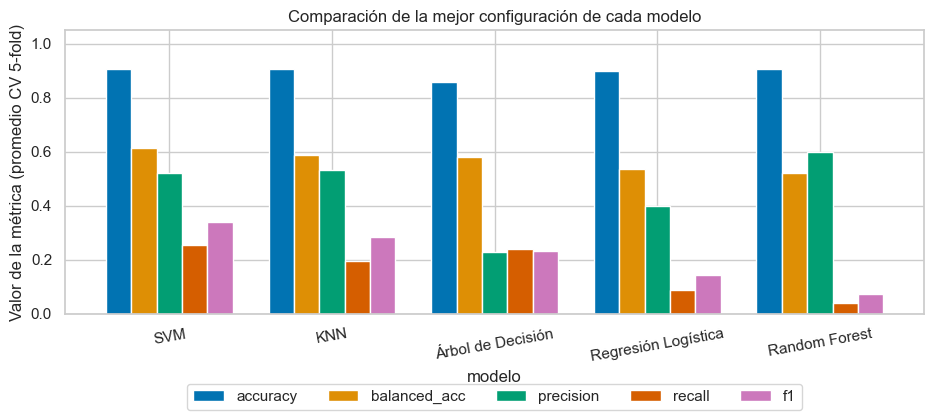

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
tabla_plot = tabla_mejores.set_index('modelo')[cols_metricas]
tabla_plot.plot.bar(ax=ax, color=PALETA[:5], width=0.78, rot=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor de la métrica (promedio CV 5-fold)')
ax.set_title('Comparación de la mejor configuración de cada modelo')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncols=5)
plt.tight_layout()
plt.savefig('figures/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Guardo todas las tablas de resultados en CSV para armar después el paper
os.makedirs('results', exist_ok=True)
slugs = {'Regresión Logística': 'logistic_regression', 'SVM': 'svm',
         'Árbol de Decisión': 'decision_tree', 'KNN': 'knn', 'Random Forest': 'random_forest'}
for nombre, tabla in tablas.items():
    tabla.to_csv(f'results/{slugs[nombre]}.csv', index=False)
tabla_mejores.to_csv('results/comparacion_modelos.csv', index=False)
print('Tablas guardadas en la carpeta results/')

Tablas guardadas en la carpeta results/


## 8. Experimento extra: reducción de dimensionalidad con PCA

Del Cap. 3 del curso: PCA proyecta los datos a las direcciones de mayor varianza. Pruebo si el mejor modelo mantiene su rendimiento usando solo las componentes que explican el **95% de la varianza** de los 40 MFCC.

In [16]:
def construir_modelo(nombre, fila):
    """Reconstruye un modelo con los hiperparámetros ganadores de su tabla."""
    if nombre == 'Regresión Logística':
        return LogisticRegression(C=fila['C'], max_iter=5000, random_state=SEED)
    if nombre == 'SVM':
        return SVC(kernel=fila['kernel'], C=fila['C'], gamma='scale', random_state=SEED)
    if nombre == 'Árbol de Decisión':
        prof = None if fila['max_depth'] == 'None' else int(fila['max_depth'])
        return DecisionTreeClassifier(criterion=fila['criterion'], max_depth=prof, random_state=SEED)
    if nombre == 'KNN':
        return KNeighborsClassifier(n_neighbors=int(fila['n_neighbors']), weights=fila['weights'])
    prof = None if fila['max_depth'] == 'None' else int(fila['max_depth'])
    return RandomForestClassifier(n_estimators=int(fila['n_estimators']), max_depth=prof,
                                  random_state=SEED)


pca = PCA(n_components=0.95, random_state=SEED).fit(X_train)
X_train_pca = pca.transform(X_train)
print(f'PCA: de {X_train.shape[1]} features pasé a {pca.n_components_} componentes (95% de la varianza)')

comparacion_pca = pd.DataFrame([
    {'features': 'MFCC originales (40)',
     **evaluar(construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor]), X_train)},
    {'features': f'PCA ({pca.n_components_} componentes)',
     **evaluar(construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor]), X_train_pca)},
])
comparacion_pca.to_csv('results/pca.csv', index=False)
comparacion_pca

PCA: de 40 features pasé a 30 componentes (95% de la varianza)


,features,accuracy,balanced_acc,precision,recall,f1
0,MFCC originales (40),0.905,0.615,0.522,0.255,0.339
1,PCA (30 componentes),0.901,0.616,0.471,0.264,0.336


## 9. Evaluación final en el conjunto de test

Recién ahora uso el test (20%) que separé al inicio: entreno el mejor modelo con **todo el train** y lo evalúo una sola vez, como pide el proyecto — matriz de confusión con los **porcentajes por clase** y el **accuracy total**.

In [17]:
mejor_modelo = construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor])
mejor_modelo.fit(X_train, y_train)
y_pred = mejor_modelo.predict(X_test)

print('Modelo elegido:', nombre_mejor, '→', dict(fila_ganadora[nombre_mejor].drop(cols_metricas)))
print()
print('Accuracy total en test:  ', round(accuracy_score(y_test, y_pred), 3))
print('Balanced accuracy en test:', round(balanced_accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], zero_division=0))

Modelo elegido: SVM → {'kernel': 'rbf', 'C': np.float64(10.0)}

Accuracy total en test:   0.879
Balanced accuracy en test: 0.694

              precision    recall  f1-score   support

    Negative       0.89      0.97      0.93       242
    Positive       0.74      0.42      0.53        48

    accuracy                           0.88       290
   macro avg       0.82      0.69      0.73       290
weighted avg       0.87      0.88      0.86       290



Matriz de confusión (conteos):
[[235   7]
 [ 28  20]]


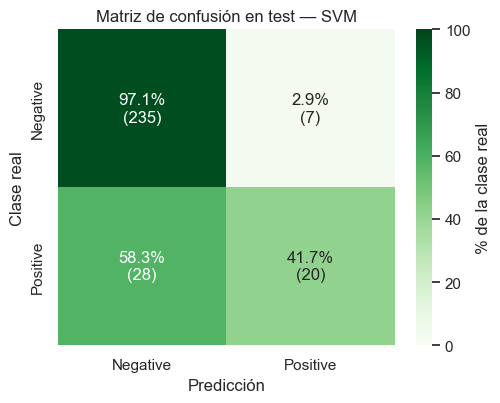

In [18]:
mc = confusion_matrix(y_test, y_pred)
mc_pct = confusion_matrix(y_test, y_pred, normalize='true') * 100

print('Matriz de confusión (conteos):')
print(mc)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
etiquetas = [[f'{pct:.1f}%\n({n})' for pct, n in zip(fila_pct, fila_n)]
             for fila_pct, fila_n in zip(mc_pct, mc)]
sns.heatmap(mc_pct, annot=etiquetas, fmt='', cmap='Greens', vmin=0, vmax=100,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': '% de la clase real'}, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Clase real')
ax.set_title(f'Matriz de confusión en test — {nombre_mejor}')
plt.tight_layout()
plt.savefig('figures/matriz_confusion_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusiones

**1. El mejor modelo fue SVM con kernel RBF (C=10).** Fue el que mejor F1 de la clase positiva obtuvo en la validación cruzada (F1=0.339, balanced accuracy=0.615), por encima de KNN (0.283), Árbol de Decisión (0.233), Regresión Logística (0.142) y Random Forest (0.074). En el test final llegó a **87.9% de accuracy** y **69.4% de balanced accuracy**.

**2. El accuracy por sí solo engaña en este dataset.** Como el 89% de los audios son negativos, casi todos los modelos superan el 90% de accuracy simplemente prediciendo "negativo" casi siempre. El caso más claro es Random Forest: tuvo el accuracy más alto (0.908) pero un recall de apenas 0.04, es decir, no detectaba prácticamente ningún caso de COVID. Por eso elegí el mejor modelo mirando el F1 y el recall de la clase positiva, no el accuracy.

**3. Detectar los positivos es la parte difícil.** En el test, el SVM identificó correctamente **20 de los 48 casos positivos (recall 42%)** y acertó en 235 de 242 negativos (97%). Sirve mucho mejor para confirmar que alguien está sano que para detectar la enfermedad. Esto es esperable: la clase positiva tiene pocos ejemplos y solo estamos usando el sonido de la tos resumido en MFCC.

**4. Reducir la dimensionalidad con PCA no cambió el resultado.** Pasar de los 40 MFCC a 30 componentes (95% de la varianza) mantuvo casi el mismo F1 (0.339 → 0.336): se puede comprimir la representación sin perder información útil, aunque tampoco mejora el modelo.

**5. El gran limitante es el desbalance 89/11.** Como trabajo futuro, para mejorar la detección de positivos se podría: balancear las clases con técnicas como `class_weight` o SMOTE (*están fuera del material del curso*), agregar más características del audio (deltas de los MFCC, chroma, mel-espectrograma) o conseguir más grabaciones positivas.

> **Nota honesta sobre el split:** la proporción de positivos quedó en 9.6% en train y 16.6% en test. Esto pasa porque unos pocos pacientes positivos aportan muchas grabaciones (el paciente 1521 tiene 22 audios) y separé los conjuntos **por paciente**, no por audio. Preferí que todas las grabaciones de una persona caigan juntas en train o en test para no inflar las métricas por fuga de datos, aunque eso desbalancee un poco las proporciones.